In [1]:
from show_img import show_img
import numpy as np
import cv2

## Part 1

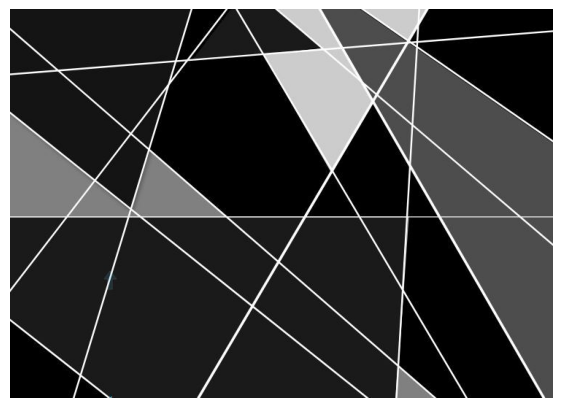

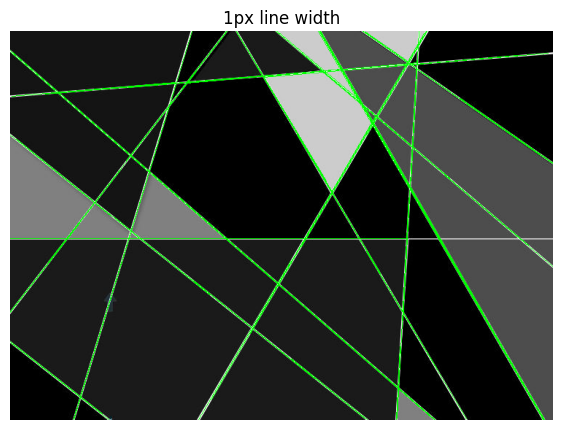

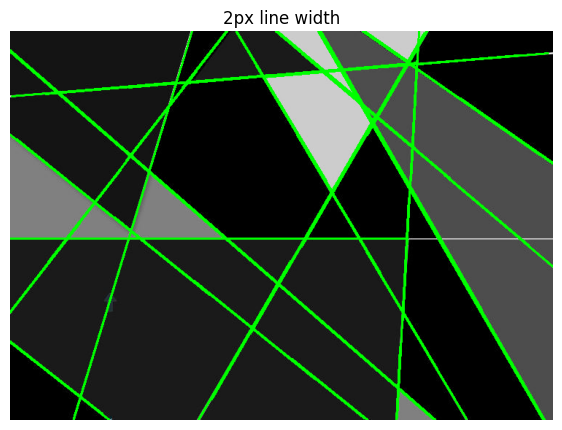

In [2]:
img = cv2.imread("lines.jpg")
show_img(img, size=7)
green = (0, 255, 0)
thres_white = 220
img_grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, mask_white = cv2.threshold(img_grayscale, thres_white, 255, cv2.THRESH_BINARY)

lines = cv2.HoughLinesP(mask_white, 1, np.pi/180, threshold=50, minLineLength=40, maxLineGap=10)
img_1p = img.copy()
img_2p = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_1p, (x1, y1), (x2, y2), green, 1)
        cv2.line(img_2p, (x1, y1), (x2, y2), green, 2)

show_img(img_1p, "1px line width", size=7)
show_img(img_2p, "2px line width", size=7)

## Part 2

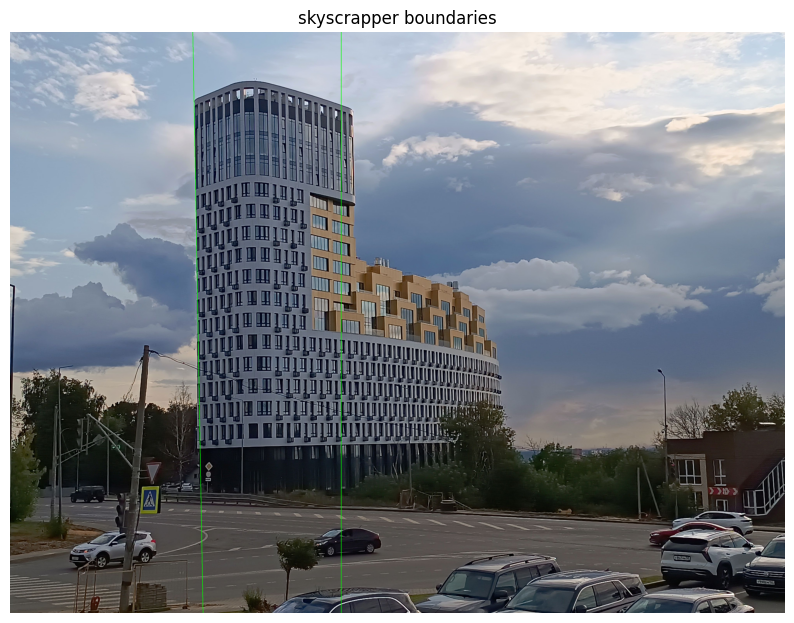

In [6]:
img_skys = cv2.imread('skyskeb_one.jpg')
img2_grayscale = cv2.cvtColor(img_skys, cv2.COLOR_BGR2GRAY)

img2_blur = cv2.GaussianBlur(img2_grayscale, (5, 5), 0)
img2_edges = cv2.Canny(img2_blur, 50, 150)
#show_img(img2_edges)

thres_hough = 380 
lines2 = cv2.HoughLines(img2_edges, 1, np.pi/180, thres_hough)

vertical_lines = []
multiplier = 3500
if lines2 is not None:
    for line in lines2:
        rho, theta = line[0]
        
        # если вертикальные
        if theta < 0.1 or theta > (np.pi - 0.1):
            x0_approx = rho * np.cos(theta)
            vertical_lines.append((x0_approx, rho, theta))

n=3
if vertical_lines:
    vertical_lines.sort(key=lambda item: item[0])
    
    left_index = n - 1
    if len(vertical_lines) > left_index:
        indices_to_draw = {left_index, len(vertical_lines) - 1}
        lines_to_draw = [vertical_lines[i] for i in indices_to_draw]
        
        for x0_approx, rho, theta in lines_to_draw:   
            k1, k2 = np.cos(theta), np.sin(theta)
            x0, y0 = k1*rho, k2*rho
            x1, y1 = int(x0 + multiplier*(-k2)), int(y0 + multiplier*k1)
            x2, y2 = int(x0 - multiplier*(-k2)), int(y0 - multiplier*k1)
            cv2.line(img_skys, (x1, y1), (x2, y2), (0, 255, 0), 2)

show_img(img_skys, "skyscrapper boundaries")

## Part 3

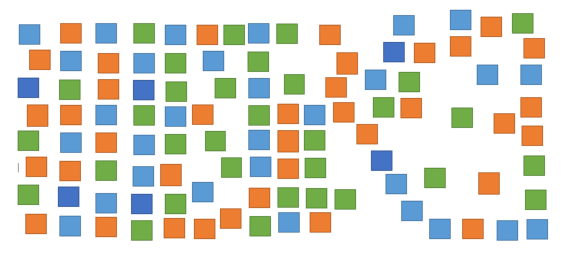

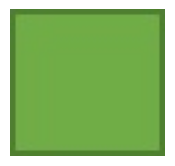

количество зелёных квадратов: 32


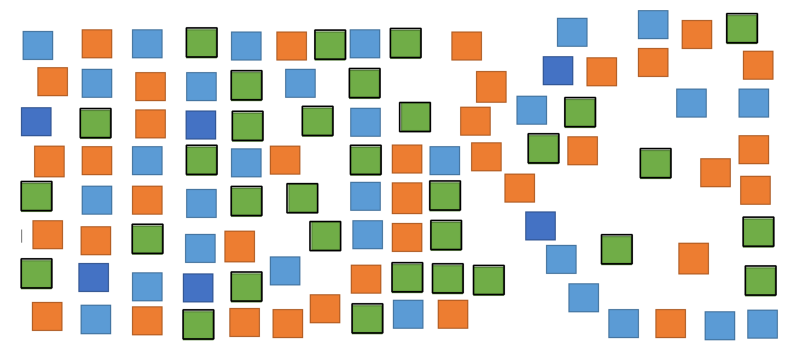

In [4]:
img3 = cv2.imread('square_many2.jpg')
template = cv2.imread('template_green.jpg')
show_img(img3, size=7)
show_img(template, size = 2)

height, width = template.shape[:2]
black = (0, 0, 0)

# TM_SQDIFF_NORMED - нахождение разности
res = cv2.matchTemplate(img3, template, cv2.TM_SQDIFF_NORMED)

threshold = 0.1
loc = np.where(res < threshold)

found_points = []
for pt in zip(*loc[::-1]):
    # если уже существует точка в окрестности
    # размера квадрата - значит повторка
    if any(abs(pt[0] - fp[0]) < width-1
           and abs(pt[1] - fp[1]) < height-1 
           for fp in found_points):
        continue

    found_points.append(pt)
    cv2.rectangle(img3, pt, (pt[0] + width, pt[1] + height), black, 2)

print(f"количество зелёных квадратов: {len(found_points)}")
show_img(img3)